# Looping Graph 
## **Objectives**:

1. Implement `looping logic` to route the flow of data back to the nodes.
2. Create a single `conditional edge` to handle decision-making and control graph flow.

## **Main Goal**: coding up `looping logic`

---

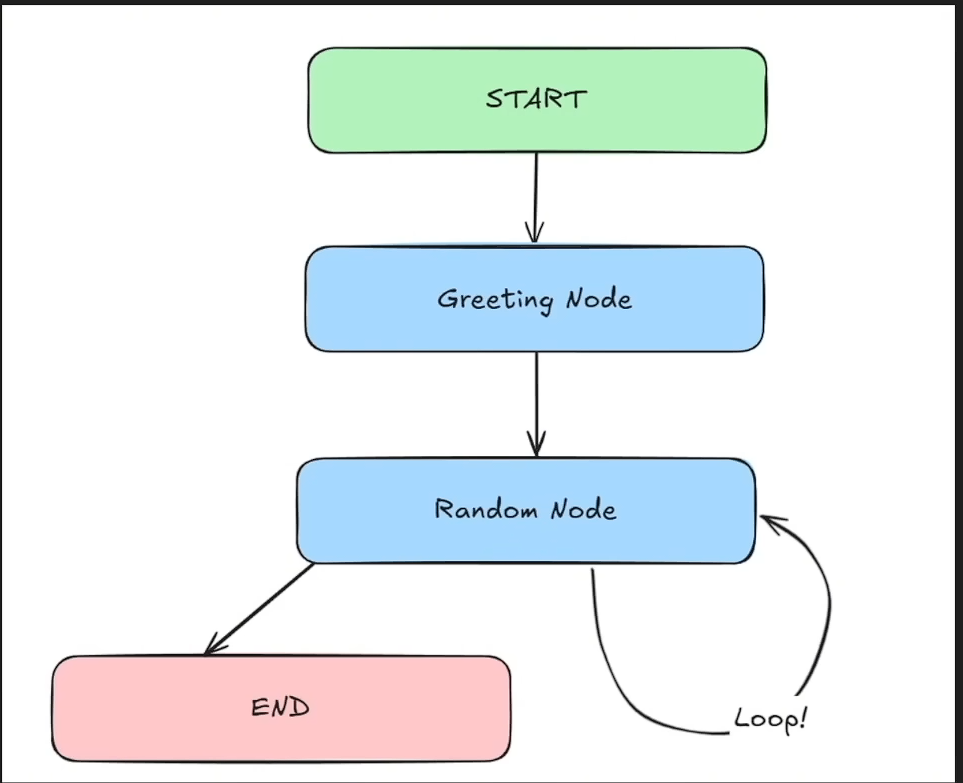

---

In [17]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

#### Create AgentState

In [18]:
class AgentState(TypedDict):
    name : str
    number : List[int]
    counter : int

#### Creating the Nodes

In [19]:
def greeting_node(state : AgentState) -> AgentState:
    """
    Greeting node which says hi to the person
    """
    state["name"] = f"Hi there, {state["name"]}"
    state["counter"] = 0
    return state


def random_node(state: AgentState) -> AgentState:
    """
    Generates a random node from 0 to 10
    """

    state["number"].append(random.randint(0 ,10))
    state["counter"] += 1
    
    return state

#### Create a conditional edge for the loop

In [20]:
def should_continue(state: AgentState) -> AgentState:
    """
    Function to decide what to do next
    """
    if state["counter"] < 5:
        print("ENTERING LOOP", state["counter"])
        return "loop" # This makes the graph to continue looping
    else:
        return "exit"

In [21]:
# Flow: greeting - random x5 - END

In [22]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random", # Source node
    should_continue, # action to do
    {
        # edge : node
        "loop" : "random", # self-loop back to the same node
        "exit": END        # end the graph
    }
)

graph.set_entry_point("greeting")

app = graph.compile()

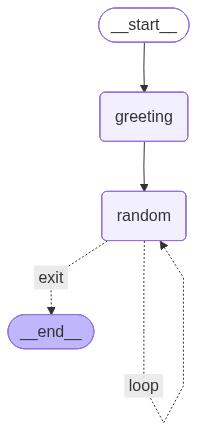

In [23]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
app.invoke({"name": "victor", "number": [], "counter": 0})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, victor', 'number': [6, 4, 6, 9, 3], 'counter': 5}

---

# Exercise

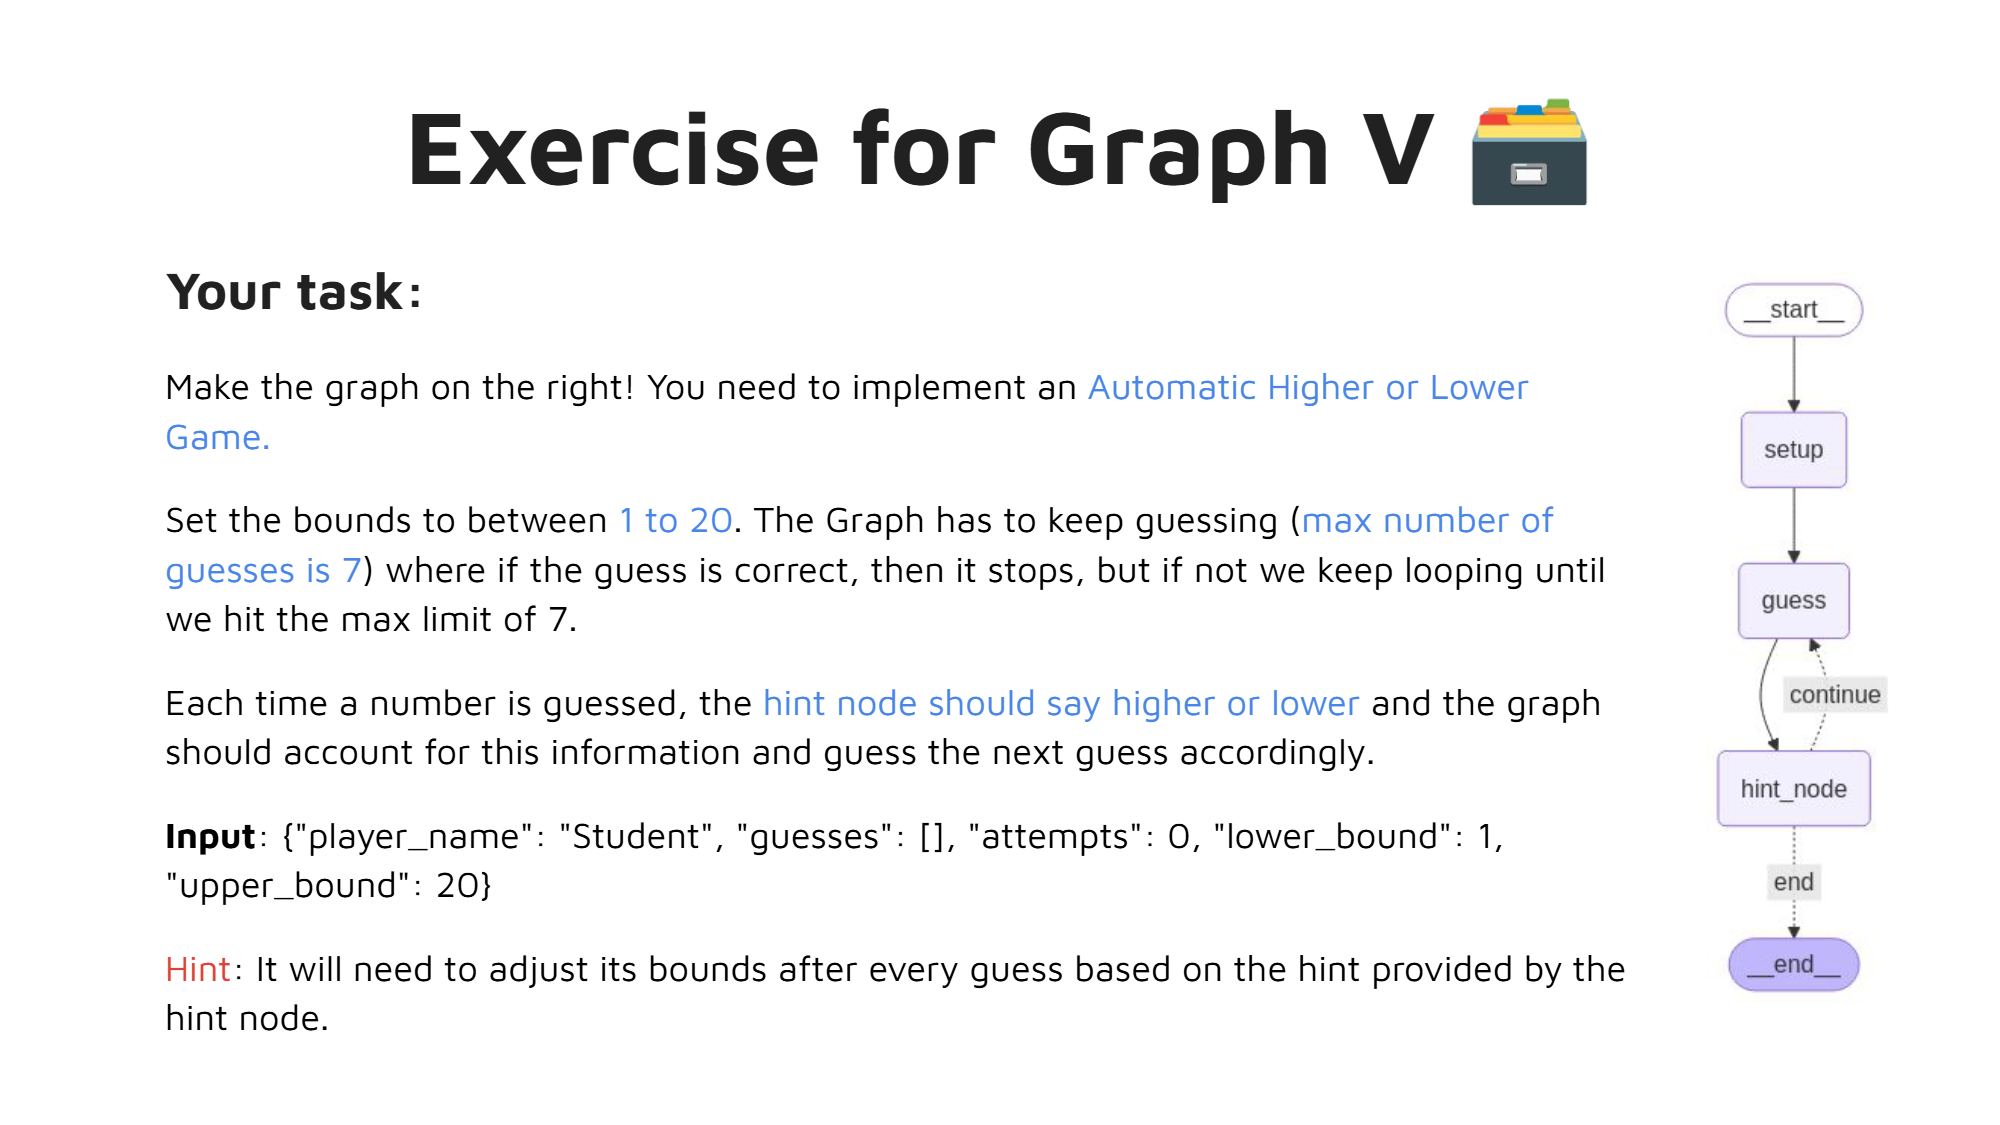

In [25]:
class AgentState(TypedDict):
    player_name : str
    guesses : List[int]
    target_number : int
    max_guesses : int
    attempts : int
    lower_bound : int 
    upper_bound : int
    hint : str

In [26]:
def setup_node(state: AgentState) -> AgentState:
    """Initialize the game with a random target number"""
    state["player_name"] = f"Welcome, {state['player_name']}!"
    state["target_number"] = random.randint(1, 20)
    state["guesses"] = []
    state["attempts"] = 0
    state["hint"] = "Game started! Try to guess the number."
    state["lower_bound"] = 1 
    state["upper_bound"] = 20 
    print(f"{state['player_name']} The game has begun. I'm thinking of a number between 1 and 20.")
    return state

In [27]:
def guess_node(state: AgentState) -> AgentState:
    """Generate a smarter guess based on previous hints"""
    
    possible_guesses = [i for i in range(state["lower_bound"], state["upper_bound"] + 1) 
                        if i not in state["guesses"]]
    if possible_guesses:
        guess = random.choice(possible_guesses)
    else:
        
        guess = random.randint(state["lower_bound"], state["upper_bound"])
    
    state["guesses"].append(guess)
    state["attempts"] += 1
    print(f"Attempt {state['attempts']}: Guessing {guess} (Current range: {state['lower_bound']}-{state['upper_bound']})")
    return state

In [28]:
def hint_node(state: AgentState) -> AgentState:
    """Here we provide a hint based on the last guess and update the bounds"""
    latest_guess = state["guesses"][-1]
    target = state["target_number"]
    
    if latest_guess < target:
        state["hint"] = f"The number {latest_guess} is too low. Try higher!"
        
        state["lower_bound"] = max(state["lower_bound"], latest_guess + 1)
        print(f"Hint: {state['hint']}")
        
    elif latest_guess > target:
        state["hint"] = f"The number {latest_guess} is too high. Try lower!"
      
        state["upper_bound"] = min(state["upper_bound"], latest_guess - 1)
        print(f"Hint: {state['hint']}")
    else:
        state["hint"] = f"Correct! You found the number {target} in {state['attempts']} attempts."
        print(f"Success! {state['hint']}")
    
    return state

In [29]:
def should_continue(state: AgentState) -> str:
    """Determine if we should continue guessing or end the game"""
    
    # There are 2 end conditions - either 7 is reached or the correct number is guessed
    
    latest_guess = state["guesses"][-1]
    if latest_guess == state["target_number"]:
        print(f"GAME OVER: Number found!")
        return "end"
    elif state["attempts"] >= 7:
        print(f"GAME OVER: Maximum attempts reached! The number was {state['target_number']}")
        return "end"
    else:
        print(f"CONTINUING: {state['attempts']}/7 attempts used")
        return "continue"

In [30]:
graph = StateGraph(AgentState)
graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint_node", hint_node)  


graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")  


graph.add_conditional_edges(
    "hint_node", 
    should_continue,
    {
        "continue": "guess",
        "end": END
    }
)

graph.set_entry_point("setup")
app = graph.compile()

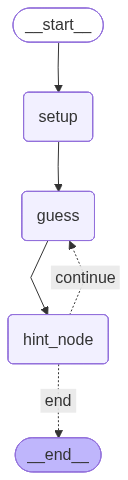

In [31]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [32]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

Welcome, Student! The game has begun. I'm thinking of a number between 1 and 20.
Attempt 1: Guessing 20 (Current range: 1-20)
Hint: The number 20 is too high. Try lower!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 15 (Current range: 1-19)
Hint: The number 15 is too low. Try higher!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 18 (Current range: 16-19)
Hint: The number 18 is too high. Try lower!
CONTINUING: 3/7 attempts used
Attempt 4: Guessing 16 (Current range: 16-17)
Hint: The number 16 is too low. Try higher!
CONTINUING: 4/7 attempts used
Attempt 5: Guessing 17 (Current range: 17-17)
Success! Correct! You found the number 17 in 5 attempts.
GAME OVER: Number found!
